In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
class UserState(TypedDict):
    name: str
    age: int
    skills: list[str]
    result: str

In [3]:
def greet_user(state: UserState) -> dict:
    greeting = f"{state['name']}, welcome to the system!"
    return {"result": greeting}

In [4]:
def describe_age(state: UserState) -> dict:
    age_desc = f"{state['result']} You are {state['age']} years old!"
    return {"result": age_desc}

In [5]:
def list_skills(state: UserState) -> dict:
    skills = state["skills"]
    if len(skills) > 1:
        formatted_skills = ", ".join(skills[:-1]) + f", and {skills[-1]}"
    elif skills:
        formatted_skills = skills[0]
    else:
        formatted_skills = "none"

    final_msg = f"{state['result']} You have skills in: {formatted_skills}"
    return {"result": final_msg}

In [6]:
builder = StateGraph(UserState)

In [7]:
builder.add_node("greet_user", greet_user)
builder.add_node("describe_age", describe_age)
builder.add_node("list_skills", list_skills)

In [8]:
builder.add_edge(START, "greet_user")
builder.add_edge("greet_user", "describe_age")
builder.add_edge("describe_age", "list_skills")
builder.add_edge("list_skills", END)

In [9]:
graph = builder.compile()

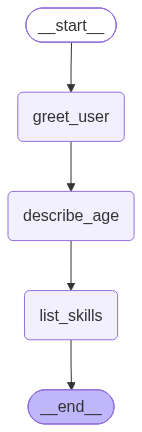

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_input = {
    "name": "Linda",
    "age": 31,
    "skills": ["Python", "Machine Learning", "LangGraph"],
}

output = graph.invoke(initial_input)
print(output["result"])

Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph
